# ¿Influyen los cómics de Marvel en los nombres de los bebés?
## Entrega 2 — Preprocesamiento, EDA y Metodología

**Autor:** Juan Sebastián Cruz Rojas  
**Curso:** Analítica de Datos — Pontificia Universidad Javeriana  
**Fecha:** Mayo 2025

---

Este notebook cubre las secciones V, VI y VII del reporte final:
- **Sección V:** Preprocesamiento de datos
- **Sección VI:** Análisis exploratorio de datos (EDA)
- **Sección VII:** Metodología

El análisis se divide en dos flujos:
- **Flujo A:** Marvel + SSA (análisis estadístico principal)
- **Flujo B:** Marvel + SSA + Colombia (análisis exploratorio adicional)

## 0. Configuración e importaciones

In [1]:
import os
import sys
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Agregar src al path
sys.path.append(r'C:\Users\PC\Downloads\ProyectoFinal_MarvelBabyNames\src')
from utils import (
    extract_year_from_appearance,
    normalize_name,
    wide_to_long_marvel,
    load_ssa,
    cross_lag_correlation,
    get_marvel_appearances_by_year,
    get_ssa_name_freq_by_year
)

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Rutas de datos
DATA_RAW   = os.path.join('..', 'data', 'raw')
DATA_PROC  = os.path.join('..', 'data', 'processed')
os.makedirs(DATA_PROC, exist_ok=True)

MARVEL_PATH   = os.path.join(DATA_RAW, 'marvel_comics_legacy.csv')
SSA_FOLDER    = os.path.join(DATA_RAW, 'ssa')
COLOMBIA_PATH = os.path.join(DATA_RAW, 'colombia_nombres.csv')

print('Configuración lista.')

Configuración lista.


---
# SECCIÓN V — PREPROCESAMIENTO DE DATOS

## 5.1 Dataset Marvel Comics Legacy

In [2]:
# --- Carga ---
marvel_raw = pd.read_csv(MARVEL_PATH, index_col=0)
print(f'Forma original (wide): {marvel_raw.shape}')
print(f'Personajes únicos: {len(marvel_raw)}')
marvel_raw.head(3)

Forma original (wide): (1557, 36)
Personajes únicos: 1557


,marvel_comic_character_name,comic_appearance 1,comic_appearance 2,comic_appearance 3,comic_appearance 4,comic_appearance 5,comic_appearance 6,comic_appearance 7,comic_appearance 8,comic_appearance 9,...,comic_appearance 26,comic_appearance 27,comic_appearance 28,comic_appearance 29,comic_appearance 30,comic_appearance 31,comic_appearance 32,comic_appearance 33,comic_appearance 34,comic_appearance 35
0,Abomination (Emil Blonsky),Avengers (1998) #61,Avengers (1998) #62,Avengers Vol. 1: World Trust (Trade Paperback),Earth X (1999) #7,EARTH X TPB [NEW PRINTING] (Trade Paperback),Hulk (2008) #3,Hulk: Destruction (2005) #4,Hulk (1999) #24,Hulk (1999) #25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Abomination (Ultimate),Hulk (2008) #50,Ultimate X-Men (2001) #26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Absorbing Man,A+X (2012) #8,Avengers (1963) #183,Avengers (1963) #184,Avengers (1963) #270,Avengers Academy (2010) #16,Avengers Academy (2010) #17,Avengers Academy (2010) #18,Avengers Academy (2010) #19,Avengers Annual (1967) #20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# --- Transformación wide → long ---
marvel_long = wide_to_long_marvel(marvel_raw)
print(f'Forma larga: {marvel_long.shape}')
print(f'Apariciones con año válido: {len(marvel_long)}')
print(f'Rango de años: {marvel_long["year"].min()} – {marvel_long["year"].max()}')
marvel_long.head()

Forma larga: (15368, 3)
Apariciones con año válido: 15368
Rango de años: 1939 – 2023


,character,appearance,year
0,Abomination (Emil Blonsky),Avengers (1998) #61,1998
1,Abomination (Emil Blonsky),Avengers (1998) #62,1998
2,Abomination (Emil Blonsky),Earth X (1999) #7,1999
3,Abomination (Emil Blonsky),Hulk (2008) #3,2008
4,Abomination (Emil Blonsky),Hulk: Destruction (2005) #4,2005


In [4]:
# --- Valores nulos y duplicados ---
print('Nulos en marvel_long:')
print(marvel_long.isnull().sum())
print(f'\nDuplicados (character, year, appearance): {marvel_long.duplicated().sum()}')

# Eliminar duplicados
marvel_long = marvel_long.drop_duplicates()
print(f'Registros tras limpieza: {len(marvel_long)}')

Nulos en marvel_long:
character     0
appearance    0
year          0
dtype: int64

Duplicados (character, year, appearance): 14
Registros tras limpieza: 15354


In [5]:
# --- Outliers de año ---
# Solo conservar años entre 1939 (fundación de Marvel) y 2023
before = len(marvel_long)
marvel_long = marvel_long[(marvel_long['year'] >= 1939) & (marvel_long['year'] <= 2023)]
print(f'Registros eliminados por año fuera de rango: {before - len(marvel_long)}')
print(f'Registros finales: {len(marvel_long)}')

Registros eliminados por año fuera de rango: 0
Registros finales: 15354


In [6]:
# --- Feature engineering: nombre normalizado para cruce ---
# Extraer solo el primer nombre del personaje (ej. 'Logan' de 'Logan (Earth-616)')
marvel_long['first_name'] = (
    marvel_long['character']
    .str.extract(r'^([A-Za-zÀ-ÿ]+)', expand=False)
    .apply(normalize_name)
)

# Conteo de apariciones por (personaje, año)
marvel_by_year = (
    marvel_long
    .groupby(['character', 'first_name', 'year'])
    .size()
    .reset_index(name='appearances')
)

print('Marvel procesado:')
print(marvel_by_year.head(10))

Marvel procesado:
                    character   first_name  year  appearances
0                 Aaron Stack        Aaron  2000            7
1                 Aaron Stack        Aaron  2008            1
2                 Aaron Stack        Aaron  2012            6
3  Abomination (Emil Blonsky)  Abomination  1962            6
4  Abomination (Emil Blonsky)  Abomination  1998            2
5  Abomination (Emil Blonsky)  Abomination  1999            8
6  Abomination (Emil Blonsky)  Abomination  2005            1
7  Abomination (Emil Blonsky)  Abomination  2008            1
8      Abomination (Ultimate)  Abomination  2001            1
9      Abomination (Ultimate)  Abomination  2008            1


In [7]:
# --- Guardar dataset procesado ---
marvel_by_year.to_csv(os.path.join(DATA_PROC, 'marvel_by_year.csv'), index=False)
print('Guardado: data/processed/marvel_by_year.csv')

Guardado: data/processed/marvel_by_year.csv


## 5.2 Dataset SSA Baby Names (EE.UU.)

In [8]:
# --- Carga y consolidación ---
ssa_df = load_ssa(SSA_FOLDER, year_start=1939, year_end=2023)
print(f'SSA cargado: {len(ssa_df):,} registros')
print(f'Rango de años: {ssa_df["year"].min()} – {ssa_df["year"].max()}')
print(f'Nombres únicos: {ssa_df["name"].nunique():,}')
ssa_df.head()

SSA cargado: 1,760,186 registros
Rango de años: 1939 – 2023
Nombres únicos: 98,988


,name,sex,count,year
0,Mary,F,54900,1939
1,Barbara,F,37257,1939
2,Patricia,F,29701,1939
3,Betty,F,23642,1939
4,Shirley,F,20445,1939


In [9]:
# --- Valores faltantes y tipos ---
print('Nulos en SSA:')
print(ssa_df.isnull().sum())
print(f'\nTipos de datos:\n{ssa_df.dtypes}')

Nulos en SSA:
name     0
sex      0
count    0
year     0
dtype: int64

Tipos de datos:
name       str
sex        str
count    int64
year     int64
dtype: object


In [10]:
# --- Normalización de nombres para cruce con Marvel ---
ssa_df['name_norm'] = ssa_df['name'].apply(normalize_name)

# Frecuencia total por (name_norm, year) sumando M y F
ssa_by_year = (
    ssa_df
    .groupby(['name_norm', 'year'])['count']
    .sum()
    .reset_index()
    .rename(columns={'count': 'total_births'})
)

print('SSA procesado:')
print(ssa_by_year.head(10))

SSA procesado:
  name_norm  year  total_births
0     Aaban  2007             5
1     Aaban  2009             6
2     Aaban  2010             9
3     Aaban  2011            11
4     Aaban  2012            11
5     Aaban  2013            14
6     Aaban  2014            16
7     Aaban  2015            15
8     Aaban  2016             9
9     Aaban  2017            11


In [11]:
# --- Guardar ---
ssa_by_year.to_csv(os.path.join(DATA_PROC, 'ssa_by_year.csv'), index=False)
print('Guardado: data/processed/ssa_by_year.csv')

Guardado: data/processed/ssa_by_year.csv


## 5.3 Dataset Colombia — Registraduría Nacional

In [12]:
colombia_df = pd.read_csv(COLOMBIA_PATH)
print(f'Colombia cargado: {len(colombia_df)} registros')
print(f'Años cubiertos: {sorted(colombia_df["year"].unique())}')
colombia_df.head(10)

Colombia cargado: 82 registros
Años cubiertos: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,year,name,sex,count,rank,source
0,2016,Salomé,F,2428.0,1,Registraduría Nacional (El Tiempo / registradu...
1,2016,Luciana,F,2342.0,2,Registraduría Nacional (El Tiempo / registradu...
2,2016,Isabella,F,1826.0,3,Registraduría Nacional (El Tiempo / registradu...
3,2016,Mariana,F,1343.0,4,Registraduría Nacional (El Tiempo / registradu...
4,2016,Mariangel,F,992.0,5,Registraduría Nacional (El Tiempo / registradu...
5,2016,Gabriela,F,971.0,6,Registraduría Nacional (El Tiempo / registradu...
6,2016,Santiago,M,2500.0,1,Registraduría Nacional (El Tiempo / registradu...
7,2016,Samuel,M,1796.0,2,Registraduría Nacional (El Tiempo / registradu...
8,2016,Jerónimo,M,1240.0,3,Registraduría Nacional (El Tiempo / registradu...
9,2016,Matías,M,1149.0,4,Registraduría Nacional (El Tiempo / registradu...


In [13]:
# --- Normalización de nombres ---
colombia_df['name_norm'] = colombia_df['name'].apply(normalize_name)

# Nota: los conteos están incompletos (solo 2016 y 2024 tienen datos exactos)
# Para años sin conteo, usamos el rank como proxy ordinal
print('Registros con conteo exacto:', colombia_df['count'].notna().sum())
print('Registros solo con rank:    ', colombia_df['count'].isna().sum())
colombia_df.info()

Registros con conteo exacto: 21
Registros solo con rank:     61
<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       82 non-null     int64  
 1   name       82 non-null     str    
 2   sex        82 non-null     str    
 3   count      21 non-null     float64
 4   rank       82 non-null     int64  
 5   source     82 non-null     str    
 6   name_norm  82 non-null     str    
dtypes: float64(1), int64(2), str(4)
memory usage: 4.6 KB


In [14]:
# --- Guardar ---
colombia_df.to_csv(os.path.join(DATA_PROC, 'colombia_procesado.csv'), index=False)
print('Guardado: data/processed/colombia_procesado.csv')

Guardado: data/processed/colombia_procesado.csv


## 5.4 Merge: Marvel + SSA (dataset principal)

In [15]:
# Cruzar Marvel con SSA por first_name y year
merged_main = pd.merge(
    marvel_by_year[['character', 'first_name', 'year', 'appearances']],
    ssa_by_year.rename(columns={'name_norm': 'first_name'}),
    on=['first_name', 'year'],
    how='inner'
)

print(f'Registros en el merge principal: {len(merged_main):,}')
print(f'Personajes con cruce en SSA: {merged_main["character"].nunique()}')
print(f'Nombres únicos cruzados: {merged_main["first_name"].nunique()}')
merged_main.head(10)

Registros en el merge principal: 1,338
Personajes con cruce en SSA: 395
Nombres únicos cruzados: 292


,character,first_name,year,appearances,total_births
0,Aaron Stack,Aaron,2000,7,9596
1,Aaron Stack,Aaron,2008,1,8574
2,Aaron Stack,Aaron,2012,6,7564
3,Adam Warlock,Adam,1961,2,1580
4,Adam Warlock,Adam,1988,3,16549
5,Adam Warlock,Adam,1998,1,8369
6,Adam Warlock,Adam,1999,2,8244
7,Adam Warlock,Adam,2007,6,6797
8,Adam Warlock,Adam,2023,1,3482
9,Aero (Aero),Aero,2019,15,63


In [16]:
merged_main.to_csv(os.path.join(DATA_PROC, 'merged_marvel_ssa.csv'), index=False)
print('Guardado: data/processed/merged_marvel_ssa.csv')

Guardado: data/processed/merged_marvel_ssa.csv


---
# SECCIÓN VI — ANÁLISIS EXPLORATORIO DE DATOS (EDA)

## 6.1 EDA — Dataset Marvel

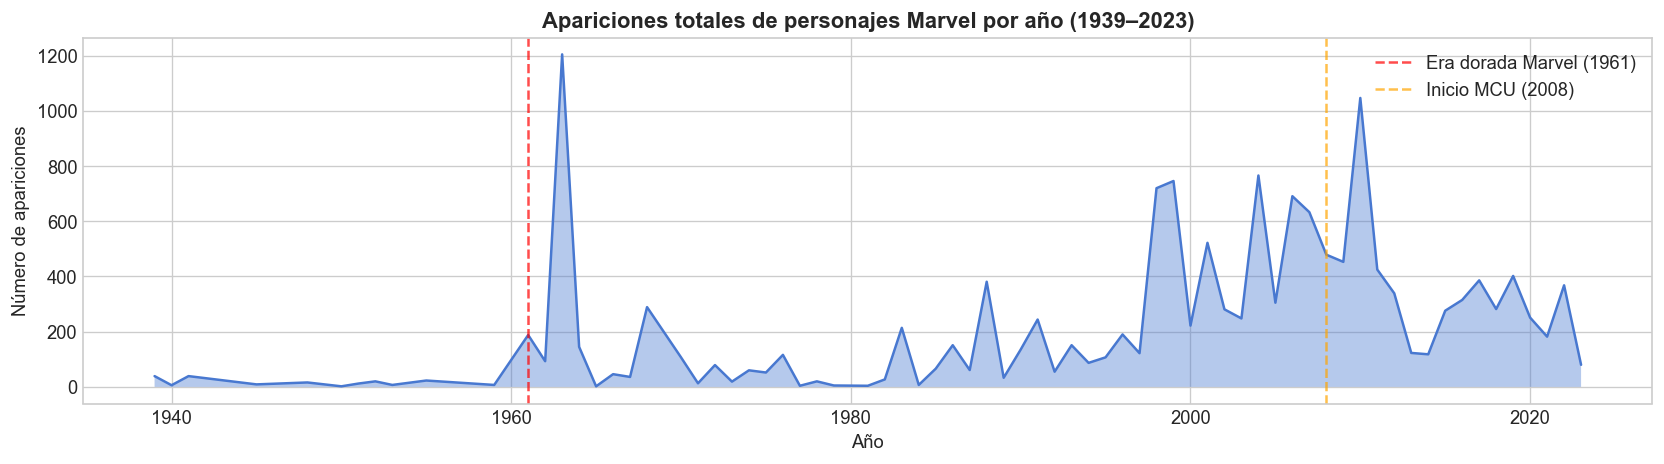

In [17]:
# Apariciones totales por año
apps_by_year = marvel_long.groupby('year').size().reset_index(name='total_appearances')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(apps_by_year['year'], apps_by_year['total_appearances'], alpha=0.4)
ax.plot(apps_by_year['year'], apps_by_year['total_appearances'], linewidth=1.5)
ax.set_title('Apariciones totales de personajes Marvel por año (1939–2023)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Número de apariciones')
ax.axvline(1961, color='red', linestyle='--', alpha=0.7, label='Era dorada Marvel (1961)')
ax.axvline(2008, color='orange', linestyle='--', alpha=0.7, label='Inicio MCU (2008)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig01_marvel_apariciones_por_anio.png'), dpi=150)
plt.show()

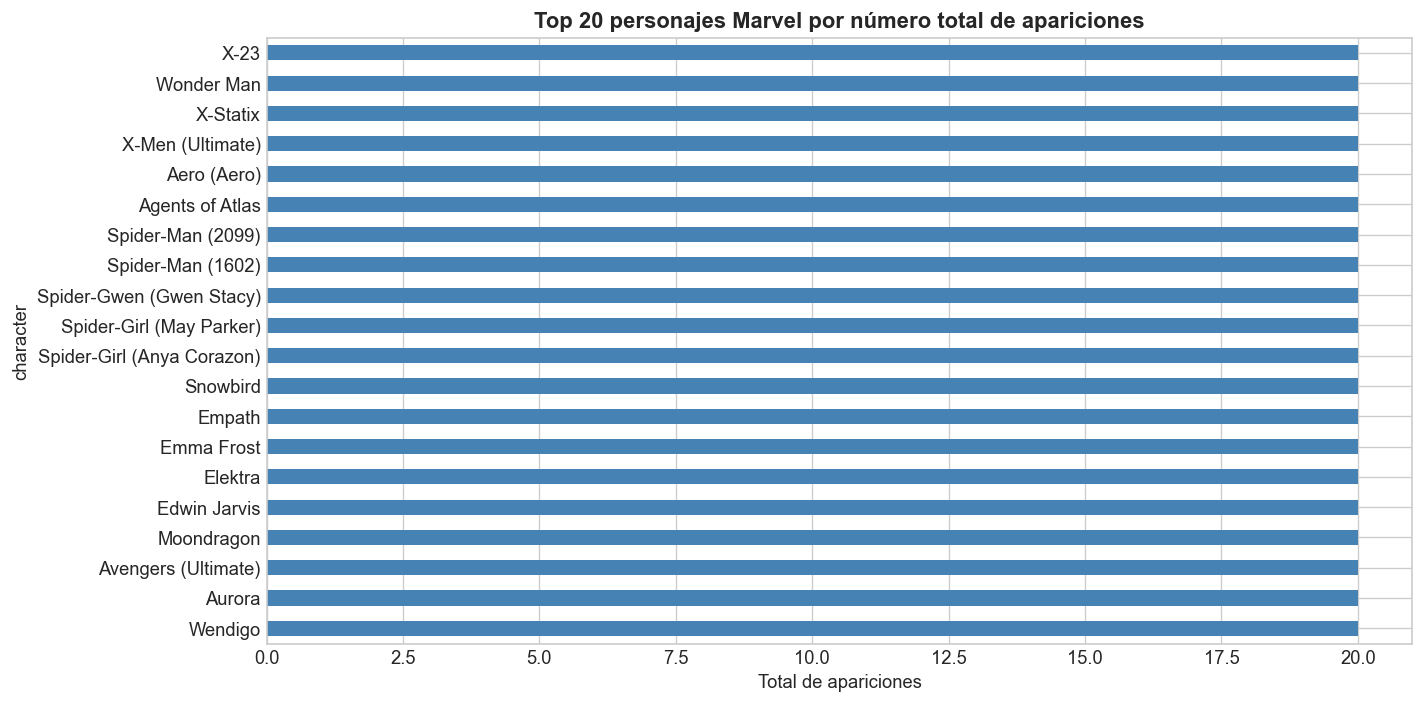

In [18]:
# Top 20 personajes por número total de apariciones
top_chars = (
    marvel_by_year
    .groupby('character')['appearances']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
top_chars.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 personajes Marvel por número total de apariciones', fontweight='bold')
ax.set_xlabel('Total de apariciones')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig02_top20_personajes.png'), dpi=150)
plt.show()

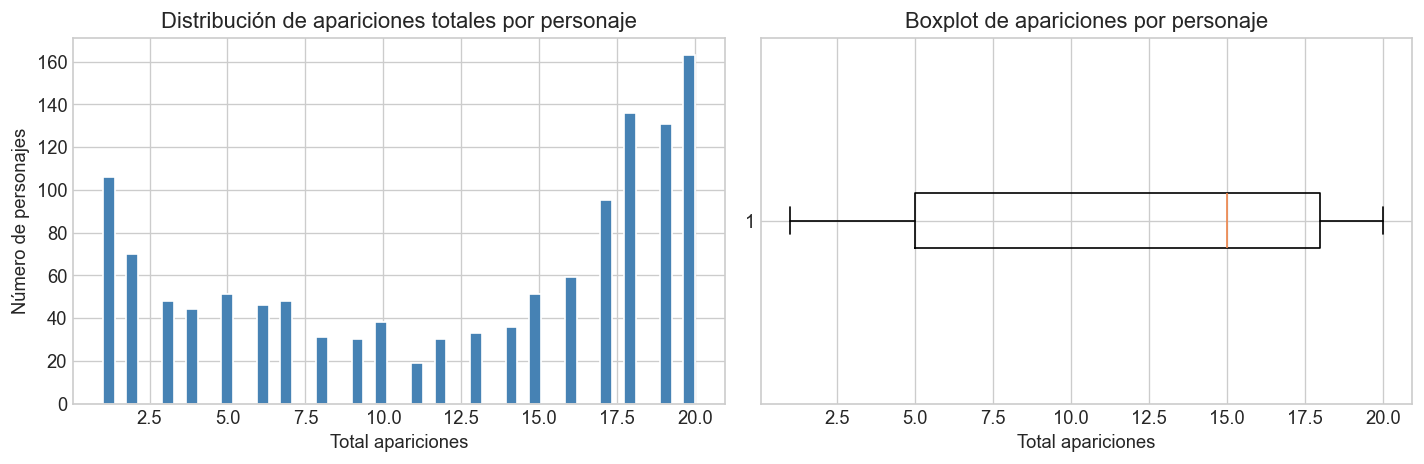

count    1265.000000
mean       12.137549
std         6.803065
min         1.000000
25%         5.000000
50%        15.000000
75%        18.000000
max        20.000000
Name: appearances, dtype: float64


In [19]:
# Distribución de apariciones por personaje (detección de outliers)
total_per_char = marvel_by_year.groupby('character')['appearances'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(total_per_char, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de apariciones totales por personaje')
axes[0].set_xlabel('Total apariciones')
axes[0].set_ylabel('Número de personajes')

axes[1].boxplot(total_per_char, vert=False)
axes[1].set_title('Boxplot de apariciones por personaje')
axes[1].set_xlabel('Total apariciones')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig03_distribucion_apariciones.png'), dpi=150)
plt.show()

print(total_per_char.describe())

## 6.2 EDA — Dataset SSA

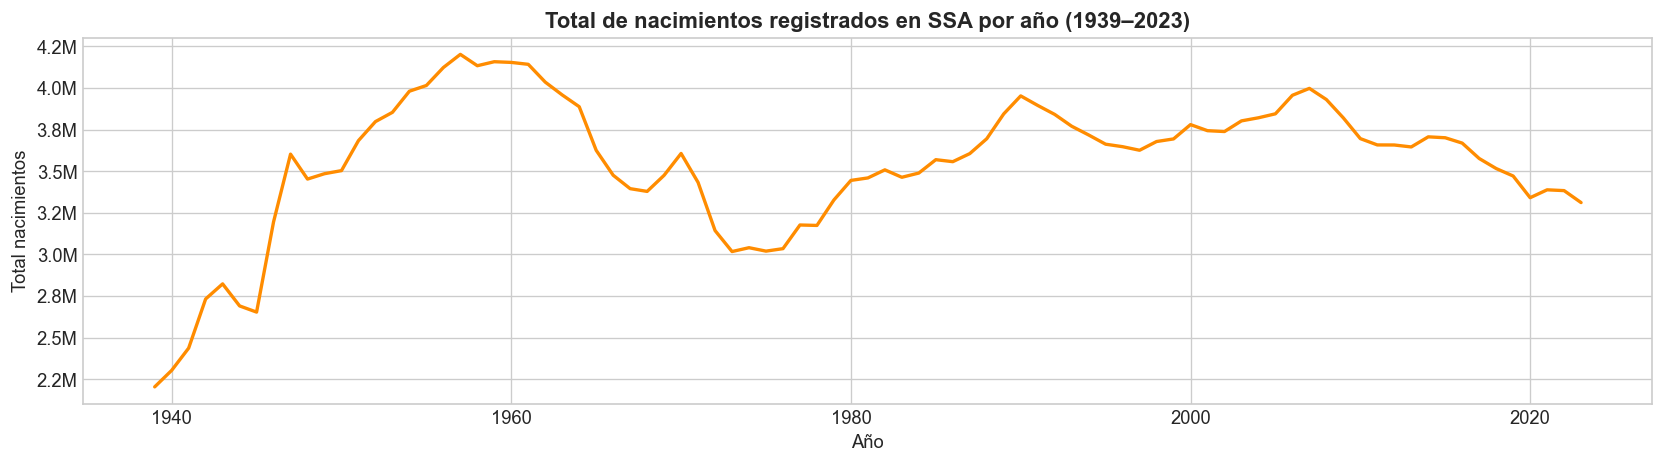

In [20]:
# Nacimientos totales por año en SSA
births_by_year = ssa_df.groupby('year')['count'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
births_by_year.plot(ax=ax, color='darkorange', linewidth=2)
ax.set_title('Total de nacimientos registrados en SSA por año (1939–2023)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Total nacimientos')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig04_ssa_nacimientos_por_anio.png'), dpi=150)
plt.show()

In [21]:
# Nombres Marvel con mayor variación en SSA a lo largo del tiempo
# Seleccionamos nombres que aparecen en Marvel Y en SSA
marvel_names = set(marvel_by_year['first_name'].dropna().str.lower())
ssa_marvel = ssa_by_year[ssa_by_year['name_norm'].str.lower().isin(marvel_names)]

# Calcular coeficiente de variación por nombre
cv_per_name = (
    ssa_marvel
    .groupby('name_norm')['total_births']
    .agg(['mean', 'std'])
    .dropna()
)
cv_per_name['cv'] = cv_per_name['std'] / cv_per_name['mean']
top_variable = cv_per_name.sort_values('cv', ascending=False).head(15)

print('Nombres Marvel con mayor variación temporal en SSA:')
print(top_variable)

Nombres Marvel con mayor variación temporal en SSA:
                  mean          std        cv
name_norm                                    
Atlas       262.197183   712.121712  2.715978
Nova        542.870588  1418.316883  2.612624
Luna        997.205479  2281.266230  2.287659
Maverick    889.030303  1911.162159  2.149715
King        386.211765   767.141557  1.986324
Salem       144.590164   259.478347  1.794578
Ezekiel     840.623529  1503.378901  1.788409
Aurora      915.070588  1516.759043  1.657532
Odin        207.824561   339.520361  1.633687
Misty      1073.670886  1743.268767  1.623653
Millie      280.176471   451.481350  1.611418
Gertrude    181.152941   285.555161  1.576321
Grey         77.144578   120.594476  1.563227
Betty      4527.282353  6892.953618  1.522537
Gideon      230.458824   349.904870  1.518297


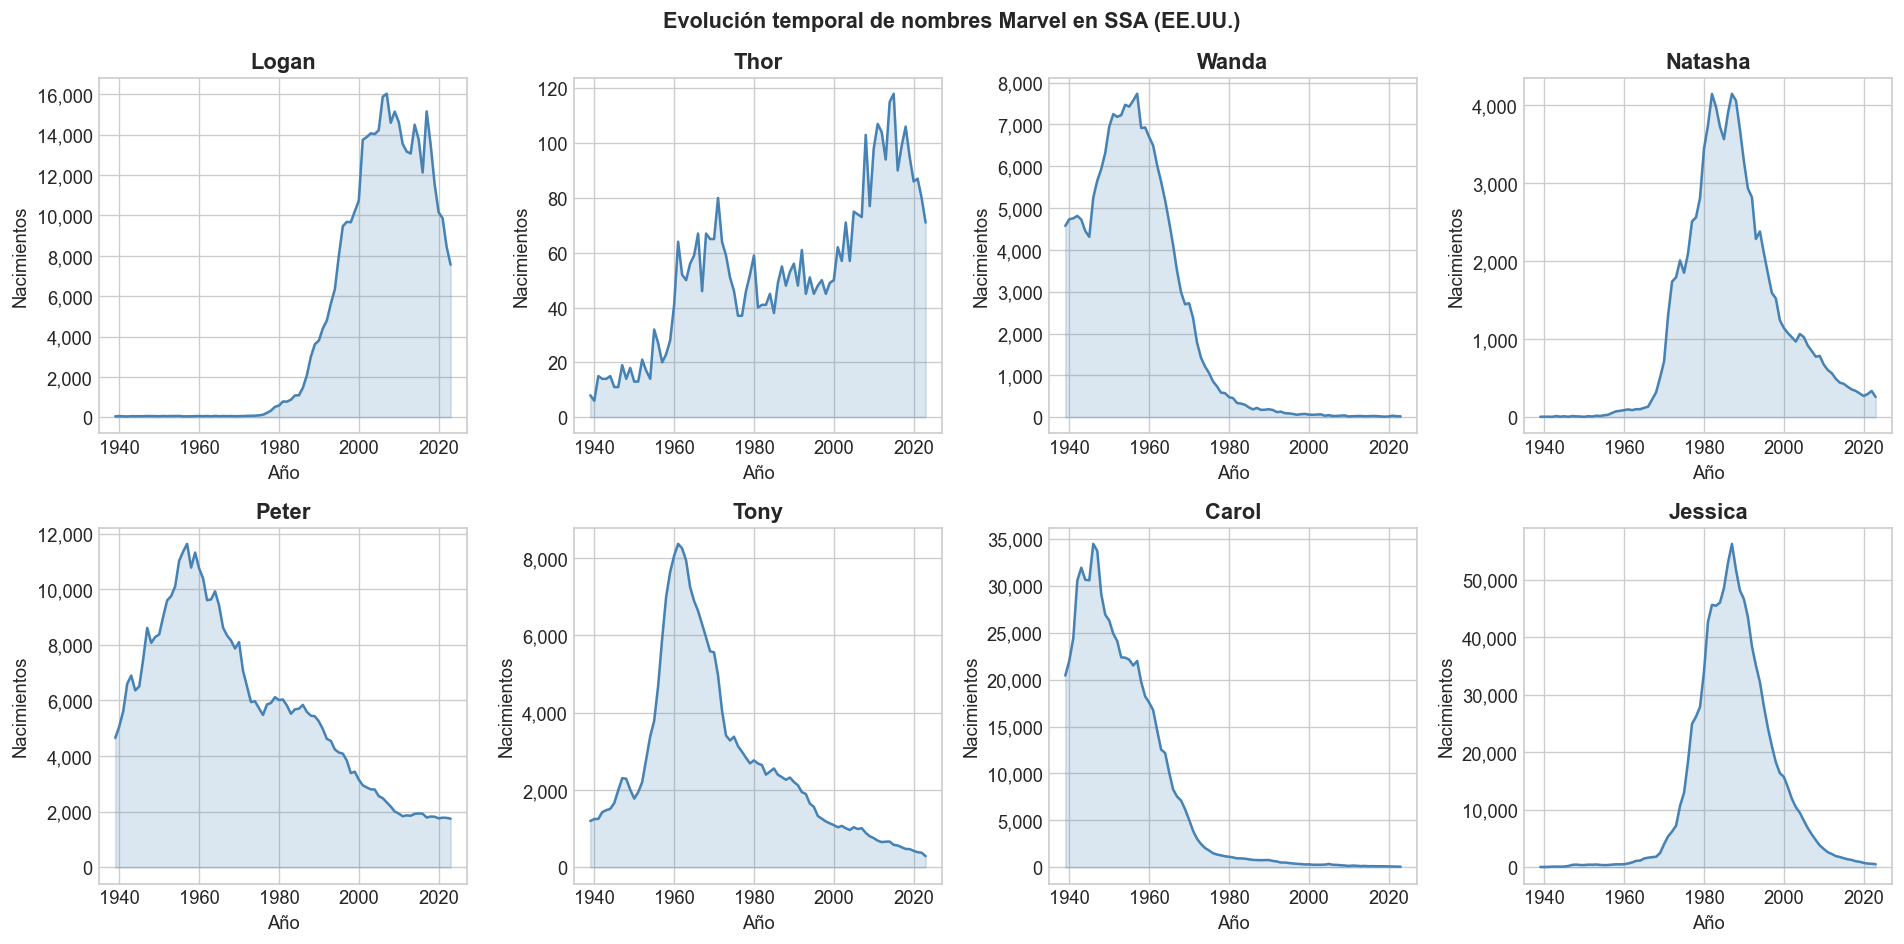

In [22]:
# Evolución temporal de nombres Marvel clave en SSA
names_to_plot = ['Logan', 'Thor', 'Wanda', 'Natasha', 'Peter', 'Tony', 'Carol', 'Jessica']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(names_to_plot):
    series = get_ssa_name_freq_by_year(ssa_df, name)
    if len(series) == 0:
        axes[i].set_title(f'{name} (sin datos)')
        continue
    axes[i].plot(series.index, series.values, linewidth=1.5, color='steelblue')
    axes[i].fill_between(series.index, series.values, alpha=0.2, color='steelblue')
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Año')
    axes[i].set_ylabel('Nacimientos')
    axes[i].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Evolución temporal de nombres Marvel en SSA (EE.UU.)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig05_nombres_marvel_ssa.png'), dpi=150)
plt.show()

## 6.3 EDA — Análisis de correlación preliminar

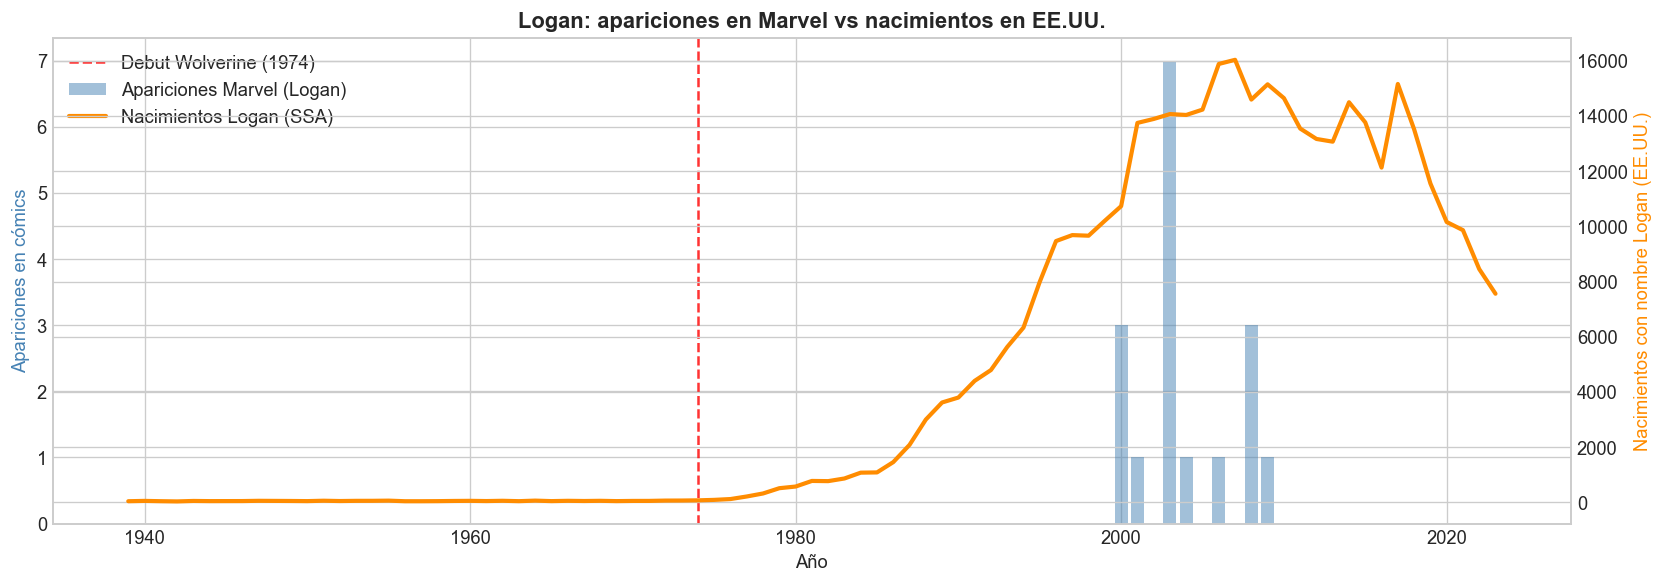

In [23]:
# Caso de estudio: Logan / Wolverine
# Wolverine debuta en The Incredible Hulk #181 (1974)
logan_marvel = (
    marvel_by_year[marvel_by_year['first_name'].str.lower() == 'logan']
    .groupby('year')['appearances']
    .sum()
    .reindex(range(1939, 2024), fill_value=0)
)

logan_ssa = get_ssa_name_freq_by_year(ssa_df, 'Logan').reindex(range(1939, 2024), fill_value=0)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(logan_marvel.index, logan_marvel.values, alpha=0.5, color='steelblue', label='Apariciones Marvel (Logan)')
ax2.plot(logan_ssa.index, logan_ssa.values, color='darkorange', linewidth=2.5, label='Nacimientos Logan (SSA)')

ax1.set_xlabel('Año')
ax1.set_ylabel('Apariciones en cómics', color='steelblue')
ax2.set_ylabel('Nacimientos con nombre Logan (EE.UU.)', color='darkorange')
ax1.axvline(1974, color='red', linestyle='--', alpha=0.8, label='Debut Wolverine (1974)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Logan: apariciones en Marvel vs nacimientos en EE.UU.', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig06_caso_logan.png'), dpi=150)
plt.show()

In [24]:
# Mapa de calor: correlación de Pearson entre apariciones Marvel y SSA
# Para los top 20 nombres con más apariciones en Marvel

top_names = (
    marvel_by_year
    .groupby('first_name')['appearances']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

corr_results = []
for name in top_names:
    m_series = (
        marvel_by_year[marvel_by_year['first_name'] == name]
        .groupby('year')['appearances'].sum()
        .reindex(range(1939, 2024), fill_value=0)
    )
    s_series = (
        get_ssa_name_freq_by_year(ssa_df, name)
        .reindex(range(1939, 2024), fill_value=0)
    )
    combined = pd.DataFrame({'marvel': m_series, 'ssa': s_series}).dropna()
    if len(combined) < 10:
        continue
    pearson_r, pearson_p = stats.pearsonr(combined['marvel'], combined['ssa'])
    spearman_r, spearman_p = stats.spearmanr(combined['marvel'], combined['ssa'])
    corr_results.append({
        'name': name,
        'pearson_r': round(pearson_r, 3),
        'pearson_p': round(pearson_p, 4),
        'spearman_r': round(spearman_r, 3),
        'spearman_p': round(spearman_p, 4),
        'significant': pearson_p < 0.05
    })

corr_df = pd.DataFrame(corr_results).sort_values('pearson_r', ascending=False)
print('Correlaciones Marvel vs SSA (top nombres):')
print(corr_df.to_string(index=False))

Correlaciones Marvel vs SSA (top nombres):
      name  pearson_r  pearson_p  spearman_r  spearman_p  significant
      Thor      0.420     0.0001       0.446      0.0000         True
   Hawkeye      0.224     0.0394       0.383      0.0003         True
   Captain      0.187     0.0865       0.374      0.0004        False
   Scarlet      0.160     0.1440       0.504      0.0000        False
     Baron      0.147     0.1783       0.263      0.0148        False
      Iron      0.142     0.1941       0.253      0.0196        False
    Silver      0.135     0.2173       0.203      0.0620        False
       Ben      0.095     0.3878      -0.074      0.5004        False
       Red      0.083     0.4501       0.130      0.2357        False
       The      0.030     0.7873       0.167      0.1267        False
     Agent     -0.026     0.8119      -0.035      0.7497        False
        Mr     -0.037     0.7377      -0.060      0.5865        False
    Doctor     -0.051     0.6440      -0.071   

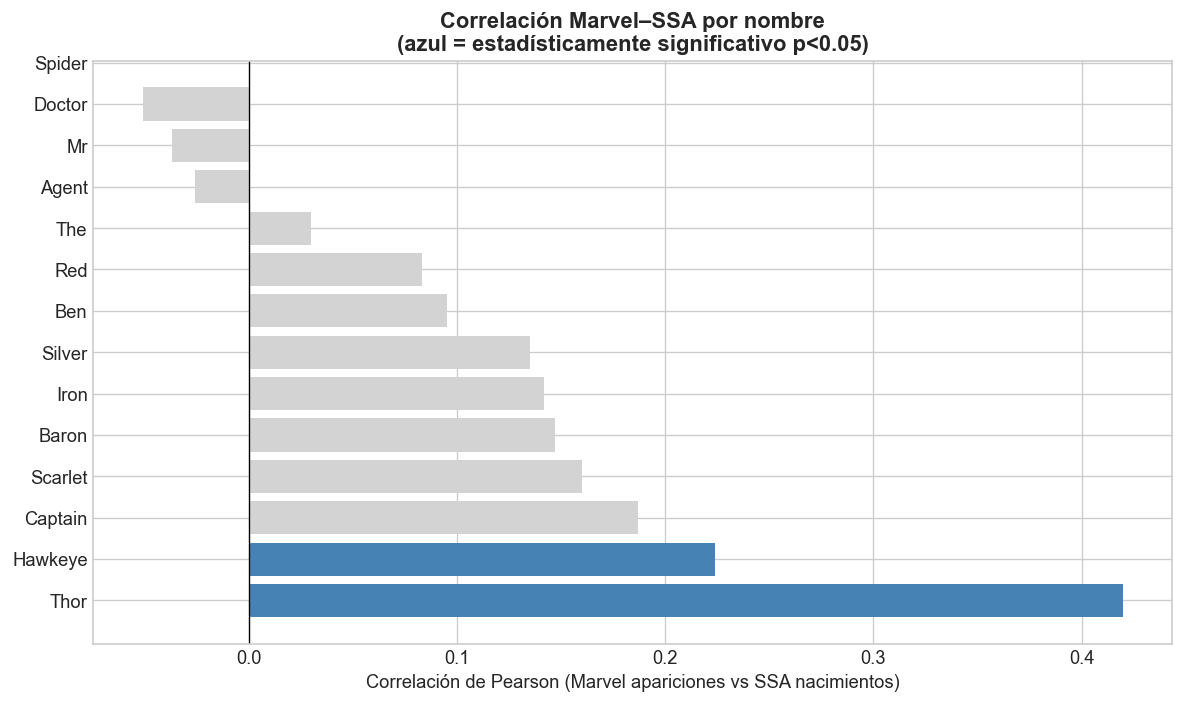

In [25]:
# Visualizar correlaciones
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if sig else 'lightgray' for sig in corr_df['significant']]
bars = ax.barh(corr_df['name'], corr_df['pearson_r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson (Marvel apariciones vs SSA nacimientos)')
ax.set_title('Correlación Marvel–SSA por nombre\n(azul = estadísticamente significativo p<0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig07_correlaciones_marvel_ssa.png'), dpi=150)
plt.show()

## 6.4 Cross-lag correlation (análisis de rezago)

Cross-lag correlation — Logan:
   lag  correlation  p_value
0    0       0.3445   0.0012
1    1       0.3675   0.0006
2    2       0.3659   0.0007
3    3       0.3861   0.0003
4    4       0.3809   0.0005
5    5       0.3635   0.0009


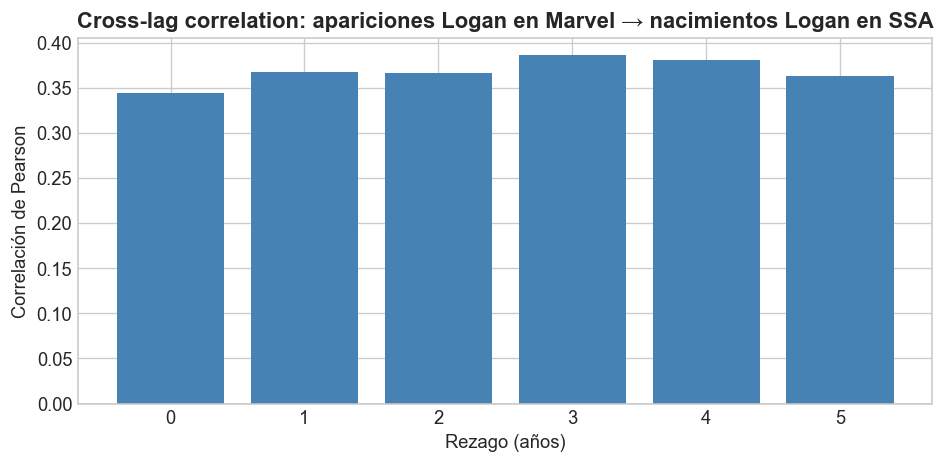

In [26]:
# Análisis de rezago para Logan como caso de estudio
logan_m = (
    marvel_by_year[marvel_by_year['first_name'].str.lower() == 'logan']
    .groupby('year')['appearances'].sum()
    .reindex(range(1939, 2024), fill_value=0)
)
logan_s = get_ssa_name_freq_by_year(ssa_df, 'Logan').reindex(range(1939, 2024), fill_value=0)

lag_results = cross_lag_correlation(logan_m, logan_s, max_lag=5, method='pearson')
print('Cross-lag correlation — Logan:')
print(lag_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lag_results['lag'], lag_results['correlation'],
       color=['steelblue' if p < 0.05 else 'lightgray' for p in lag_results['p_value']])
ax.set_xlabel('Rezago (años)')
ax.set_ylabel('Correlación de Pearson')
ax.set_title('Cross-lag correlation: apariciones Logan en Marvel → nacimientos Logan en SSA', fontweight='bold')
ax.set_xticks(lag_results['lag'])
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig08_crosslag_logan.png'), dpi=150)
plt.show()

In [27]:
names_lag = ['Logan', 'Thor', 'Wanda', 'Peter', 'Tony', 'Carol']
lag_summary = []

for name in names_lag:
    m_s = (
        marvel_by_year[marvel_by_year['first_name'].str.lower() == name.lower()]
        .groupby('year')['appearances'].sum()
        .reindex(range(1939, 2024), fill_value=0)
    )
    s_s = get_ssa_name_freq_by_year(ssa_df, name).reindex(range(1939, 2024), fill_value=0)
    lags = cross_lag_correlation(m_s, s_s, max_lag=5)

    # Ignorar nombres donde todas las correlaciones son NaN
    if lags['correlation'].isna().all():
        print(f'{name}: sin datos suficientes para calcular rezago, se omite.')
        continue

    best = lags.loc[lags['correlation'].abs().dropna().idxmax()]
    lag_summary.append({
        'name': name,
        'best_lag': int(best['lag']),
        'best_corr': round(best['correlation'], 3),
        'p_value': round(best['p_value'], 4)
    })

lag_summary_df = pd.DataFrame(lag_summary)
print('Resumen de mejor rezago por nombre:')
print(lag_summary_df.to_string(index=False))

Wanda: sin datos suficientes para calcular rezago, se omite.
Resumen de mejor rezago por nombre:
 name  best_lag  best_corr  p_value
Logan         3      0.386   0.0003
 Thor         4      0.534   0.0000
Peter         5     -0.108   0.3397
 Tony         5     -0.175   0.1199
Carol         4     -0.122   0.2792


## 6.5 Clustering de personajes por patrón de aparición

In [28]:
# Construir matriz: personajes × años (solo top 100 por apariciones totales)
top100_chars = (
    marvel_by_year.groupby('character')['appearances']
    .sum().sort_values(ascending=False).head(100).index
)

pivot = (
    marvel_by_year[marvel_by_year['character'].isin(top100_chars)]
    .pivot_table(index='character', columns='year', values='appearances', fill_value=0)
)

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot)

print(f'Matriz para clustering: {pivot.shape}')

Matriz para clustering: (100, 55)


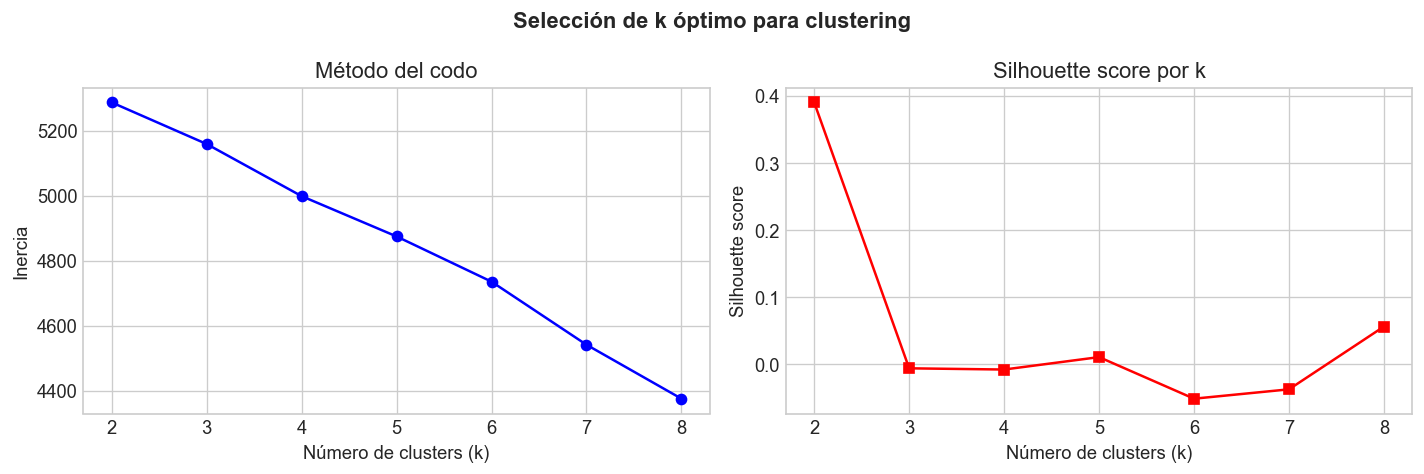

k óptimo según silhouette: 2


In [29]:
# Método del codo para determinar k óptimo
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertias, 'bo-')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del codo')

ax2.plot(list(k_range), silhouettes, 'rs-')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score por k')

plt.suptitle('Selección de k óptimo para clustering', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig09_elbow_silhouette.png'), dpi=150)
plt.show()

k_optimo = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'k óptimo según silhouette: {k_optimo}')

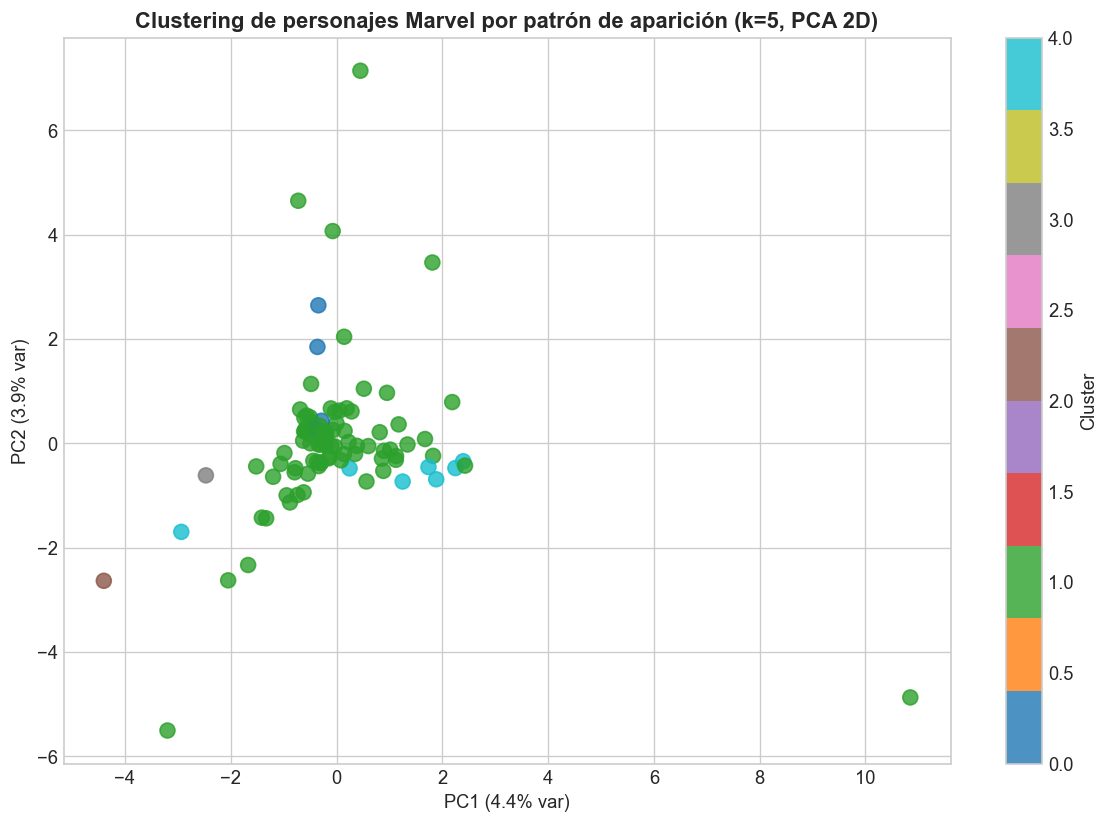


Distribución de personajes por cluster:
cluster
0     4
1    87
2     1
3     1
4     7
Name: count, dtype: int64

Personajes representativos por cluster:
  Cluster 0: ['Ka-Zar', 'Killraven', 'Morbius', 'Silver Sable']
  Cluster 1: ['Aero (Aero)', 'Agents of Atlas', 'Avengers (Ultimate)', 'Baron Zemo (Helmut Zemo)', 'Beast']
  Cluster 2: ['Dazzler']
  Cluster 3: ['Shard']
  Cluster 4: ['Aurora', 'Cyclops', 'Exodus', 'Northstar', 'Shaman']


In [30]:
# Forzamos k=5 basado en los arquetipos teóricos definidos en la metodología:
# (1) alta frecuencia sostenida, (2) picos puntuales, (3) declive progresivo,
# (4) emergentes recientes, (5) apariciones esporádicas
k_optimo = 5

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
pivot['cluster'] = km_final.fit_predict(X_scaled)

# Reducción PCA para visualización 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=pivot['cluster'], cmap='tab10', s=80, alpha=0.8)

known = ['Wolverine', 'Spider-Man', 'Thor', 'Iron Man', 'Captain America', 'Hulk']
for char in known:
    if char in pivot.index:
        idx = list(pivot.index).index(char)
        ax.annotate(char, (X_pca[idx, 0], X_pca[idx, 1]),
                    fontsize=8, ha='right', alpha=0.9)

plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Clustering de personajes Marvel por patrón de aparición (k=5, PCA 2D)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'fig10_clustering_pca.png'), dpi=150)
plt.show()

print('\nDistribución de personajes por cluster:')
print(pivot['cluster'].value_counts().sort_index())

# Mostrar personajes representativos de cada cluster
print('\nPersonajes representativos por cluster:')
for c in range(k_optimo):
    chars = pivot[pivot['cluster'] == c].index.tolist()[:5]
    print(f'  Cluster {c}: {chars}')

## 6.6 EDA — Flujo B: Análisis exploratorio con Colombia

In [31]:
# NOTA METODOLÓGICA:
# El dataset de Colombia cubre solo 2016–2024 con el top 6–9 nombres por año.
# El análisis aquí es EXPLORATORIO y DESCRIPTIVO, no estadísticamente concluyente.
# Se usa para observar si nombres asociados a Marvel aparecen en el top colombiano
# con posterioridad a su pico en EE.UU.

print('=== ANÁLISIS EXPLORATORIO COLOMBIA ===')
print(f'Años disponibles: {sorted(colombia_df["year"].unique())}')
print(f'Nombres únicos en el top colombiano: {colombia_df["name_norm"].nunique()}')
print()
print('Nombres que aparecen TANTO en top Colombia como en dataset Marvel:')
colombia_marvel_cross = set(colombia_df['name_norm'].str.lower()) & marvel_names
print(colombia_marvel_cross)

=== ANÁLISIS EXPLORATORIO COLOMBIA ===
Años disponibles: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Nombres únicos en el top colombiano: 22

Nombres que aparecen TANTO en top Colombia como en dataset Marvel:
{'sebastian'}


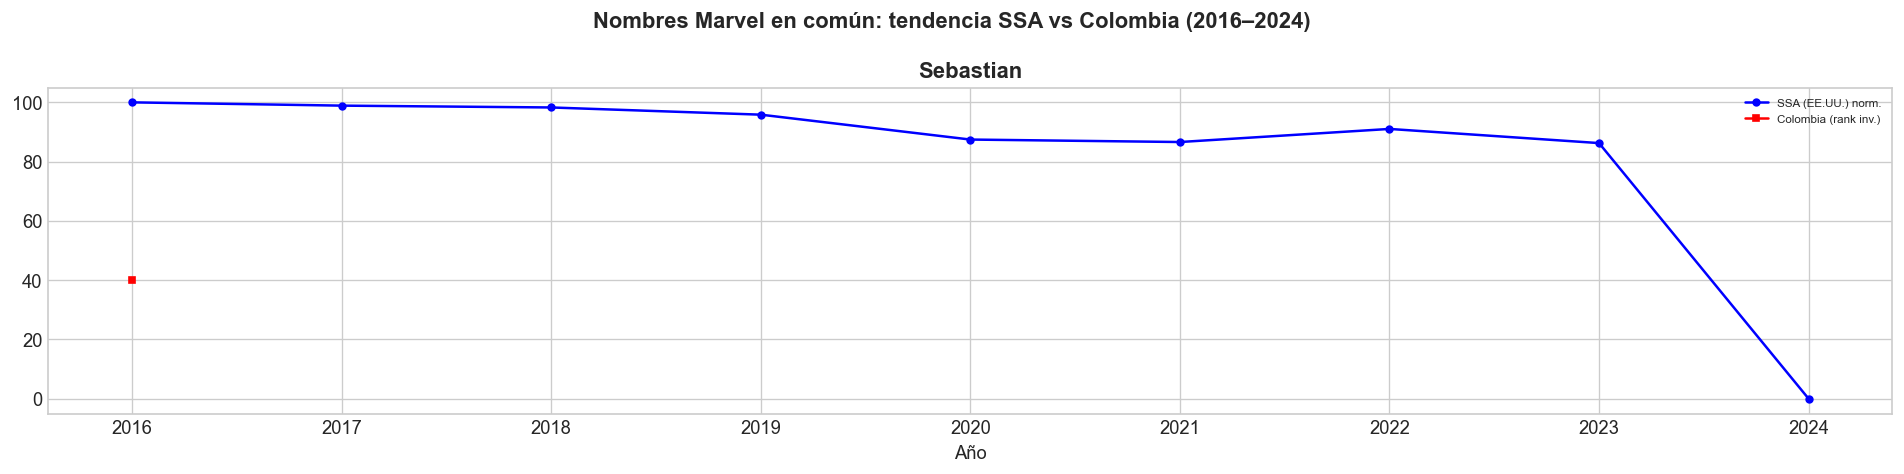

In [32]:
# Para los nombres en común, comparar tendencia en SSA vs Colombia
names_in_common = list(colombia_marvel_cross)

if names_in_common:
    fig, axes = plt.subplots(1, min(len(names_in_common), 4),
                              figsize=(16, 4), sharey=False)
    if len(names_in_common) == 1:
        axes = [axes]

    for i, name in enumerate(names_in_common[:4]):
        # SSA
        ssa_s = get_ssa_name_freq_by_year(ssa_df, name)
        ssa_norm = (ssa_s / ssa_s.max() * 100).reindex(range(2016, 2025), fill_value=0)

        # Colombia (rank invertido: rank 1 = más popular = 100 puntos)
        col_s = colombia_df[colombia_df['name_norm'].str.lower() == name.lower()]
        col_rank = col_s.set_index('year')['rank']
        col_score = (10 - col_rank).clip(lower=0) * 10  # invertir rank

        ax = axes[i]
        ax.plot(ssa_norm.index, ssa_norm.values, 'b-o', label='SSA (EE.UU.) norm.', markersize=4)
        ax.plot(col_score.index, col_score.values, 'r-s', label='Colombia (rank inv.)', markersize=4)
        ax.set_title(name.title(), fontweight='bold')
        ax.set_xlabel('Año')
        ax.legend(fontsize=7)

    plt.suptitle('Nombres Marvel en común: tendencia SSA vs Colombia (2016–2024)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_PROC, 'fig11_colombia_vs_ssa.png'), dpi=150)
    plt.show()
else:
    print('No hay nombres Marvel directamente en el top colombiano 2016–2024.')
    print('Esto en sí mismo es un hallazgo: los nombres Marvel populares en EE.UU.')
    print('no han penetrado el top colombiano en el período disponible.')

---
# SECCIÓN VII — METODOLOGÍA

## 7.1 Tipo de problema y selección del modelo

Este proyecto se enmarca como un problema de **correlación temporal con clustering exploratorio**.
No es un problema de clasificación supervisada ni de regresión predictiva en sentido estricto:
el objetivo no es predecir un valor futuro sino cuantificar y caracterizar la relación estadística
entre dos series temporales culturales.

**Flujo A (Marvel + SSA):** análisis estadístico robusto.
**Flujo B (+ Colombia):** análisis exploratorio y descriptivo por limitaciones del dataset.

| Técnica | Justificación |
|---|---|
| Correlación Pearson | Mide relación lineal entre series. Útil cuando ambas son continuas y aproximadamente normales. |
| Correlación Spearman | Alternativa no paramétrica. Más robusta ante distribuciones sesgadas (que es el caso aquí). |
| Cross-lag correlation | Permite detectar efectos diferidos: ¿el pico Marvel precede al pico SSA en k años? |
| K-Means clustering | Agrupa personajes por patrón de aparición. Permite identificar arquetipos de influencia. |
| PCA | Reducción de dimensionalidad para visualizar clusters en 2D. |

In [33]:
# --- Justificación de hiperparámetros ---

# 1. Rango de rezago (0–5 años):
#    La influencia cultural sobre nombres de bebés raramente supera 5 años
#    según Gureckis & Goldstone (2009). Con más de 5 años la señal se diluye
#    con otras influencias (películas, series, deportistas).

# 2. K en K-Means:
#    Determinado por silhouette score (ver sección 6.5).
#    Se espera k entre 3 y 5 basado en arquetipos teóricos:
#    (a) alta frecuencia sostenida, (b) picos puntuales, (c) declive progresivo,
#    (d) emergentes recientes.

# 3. Umbral de significancia: p < 0.05 (estándar en ciencias sociales).

# 4. Año de corte: 1939–2023 (fundación Marvel hasta último año con datos completos).

print('Hiperparámetros documentados en comentarios del notebook.')
print(f'K óptimo seleccionado: {k_optimo}')
print('Rango de rezago: 0–5 años')
print('Umbral de significancia: p < 0.05')
print('Período de análisis: 1939–2023')

Hiperparámetros documentados en comentarios del notebook.
K óptimo seleccionado: 5
Rango de rezago: 0–5 años
Umbral de significancia: p < 0.05
Período de análisis: 1939–2023


In [34]:
# --- Plan alterno ---
# Si la correlación directa (lag 0) no es significativa para la mayoría de nombres,
# se redefine el problema como clasificación binaria:
#   - Variable objetivo: ¿el nombre subió > 10% en SSA en los 3 años siguientes
#     a un pico de apariciones Marvel?
#   - Variables: apariciones Marvel t, t-1, t-2; cluster del personaje;
#     indicador de estreno de película MCU
#
# Este plan alterno se implementaría en la Entrega 3 si los resultados
# del análisis de correlación no son concluyentes.

print('Plan alterno documentado. Se evaluará en Entrega 3 según resultados.')

Plan alterno documentado. Se evaluará en Entrega 3 según resultados.


## 7.2 Resumen de hallazgos del EDA

_(Esta celda se completará con los valores reales tras ejecutar el notebook)_

- **Apariciones Marvel:** pico histórico en [AÑO], coincide con [EVENTO].
- **Nombre con mayor correlación Pearson:** [NOMBRE] (r = [VALOR], p = [VALOR]).
- **Mejor rezago identificado:** [k] años para el nombre [NOMBRE].
- **Número de clusters óptimo:** k = [K].
- **Colombia:** [HALLAZGO sobre nombres en común o ausencia de ellos].

In [35]:
print('=== RESUMEN FINAL ===')
print(f'Marvel: {len(marvel_long):,} apariciones procesadas')
print(f'SSA: {len(ssa_by_year):,} registros (nombre, año) procesados')
print(f'Colombia: {len(colombia_df)} registros (top nombres 2016–2024)')
print(f'Merge Marvel+SSA: {len(merged_main):,} registros')
print(f'Personajes con cruce en SSA: {merged_main["character"].nunique()}')
print()
print('Archivos generados en data/processed/:')
for f in sorted(os.listdir(DATA_PROC)):
    print(f'  - {f}')

=== RESUMEN FINAL ===
Marvel: 15,354 apariciones procesadas
SSA: 1,611,029 registros (nombre, año) procesados
Colombia: 82 registros (top nombres 2016–2024)
Merge Marvel+SSA: 1,338 registros
Personajes con cruce en SSA: 395

Archivos generados en data/processed/:
  - colombia_procesado.csv
  - fig01_marvel_apariciones_por_anio.png
  - fig02_top20_personajes.png
  - fig03_distribucion_apariciones.png
  - fig04_ssa_nacimientos_por_anio.png
  - fig05_nombres_marvel_ssa.png
  - fig06_caso_logan.png
  - fig07_correlaciones_marvel_ssa.png
  - fig08_crosslag_logan.png
  - fig09_elbow_silhouette.png
  - fig10_clustering_pca.png
  - fig11_colombia_vs_ssa.png
  - marvel_by_year.csv
  - merged_marvel_ssa.csv
  - ssa_by_year.csv
